In [1]:
import hierarchical_binary_quantization.hbq as hbq
import torch
import lpips
batches, vector_lenght = 3,8
z = torch.rand(batches,vector_lenght) * 2 - 1
z

tensor([[ 0.3795,  0.1564, -0.3776, -0.5381,  0.9325, -0.5679, -0.8639,  0.2372],
        [-0.7091, -0.5161,  0.4064,  0.9713,  0.8236, -0.0427,  0.1623,  0.0550],
        [-0.6629, -0.0943, -0.9142, -0.8737, -0.6600,  0.1573,  0.9831,  0.5852]])

In [2]:
from hierarchical_binary_quantization.example_autoencoder import ExampleAutoencoder
autoencoder = ExampleAutoencoder()
imgs = torch.rand(batches,3,256,256)
reconstructions, latents = autoencoder.forward(imgs)

In [3]:
!uv add tqdm

Resolved 50 packages in 0.79ms
Checked 49 packages in 0.89ms


In [4]:
!ls data

256x256        chat.json.full  MNIST		    README.md
cats_and_dogs  fantasy	       pokemon_archive	    yugioh
chat.json      fantasy.zip     pokemon_archive.zip


In [5]:
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from torchvision.datasets import ImageFolder

from hierarchical_binary_quantization.example_autoencoder import ExampleAutoencoder, ExampleQuantizingAutoencoder

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
])

from pathlib import Path
from PIL import Image
from torch.utils.data import Dataset

class ImageDataset(Dataset):
    def __init__(self, root, transform=None):
        self.transform = transform

        exts = ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp")

        self.files = []
        for ext in exts:
            self.files.extend(Path(root).rglob(ext))

        self.files = sorted(self.files)

        print(f"Found {len(self.files)} images.")

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img = Image.open(self.files[idx]).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img

train_dataset = ImageDataset(
    root="./data/256x256/fantasy",
    transform=transform,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True,
    num_workers=0,
)

print(f"{len(train_dataset)} training images")

/home/ron/proj/hierarchical-binary-quantization/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Found 12814 images.
12814 training images


In [6]:

autoencoder = ExampleQuantizingAutoencoder().to(device)

optimizer = torch.optim.AdamW(
    autoencoder.parameters(),
    lr=1e-4,
    weight_decay=1e-4,
)

print(
    f"Parameters: {sum(p.numel() for p in autoencoder.parameters())/1e6:.2f}M"
)

Parameters: 9.16M


In [7]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import torch


def q_out_to_rgb(q_out):
    """
    q_out: (B,C,H,W)

    Returns:
        (B,H,W,3) float tensor in [0,1]
    """

    B, C, H, W = q_out.shape
    rgb_images = []

    for b in range(B):
        # (C,H,W) -> (H*W,C)
        x = q_out[b].permute(1, 2, 0).reshape(-1, C)

        x = x.detach().cpu().numpy()

        rgb = PCA(n_components=3, whiten=True).fit_transform(x)

        # Normalize each component independently
        rgb -= rgb.min(axis=0, keepdims=True)
        rgb /= rgb.max(axis=0, keepdims=True) + 1e-8

        rgb = torch.from_numpy(rgb.reshape(H, W, 3)).float()
        rgb_images.append(rgb)

    return torch.stack(rgb_images)


def show_reconstructions(model, imgs):
    """
    Displays:
        Original | Quantized latent PCA | Reconstruction
    """

    was_training = model.training
    model.eval()

    with torch.inference_mode():
        reconstructions, latents, q_out, token_ids = model(imgs[:1])

    if was_training:
        model.train()

    original = imgs[0].detach().cpu().permute(1,2,0).clamp(0,1)
    reconstruction = reconstructions[0].detach().cpu().permute(1,2,0).clamp(0,1)
    latent_rgb = q_out_to_rgb(q_out)[0]

    fig, axes = plt.subplots(1, 3, figsize=(12,4))

    axes[0].imshow(original)
    axes[0].set_title("Original")
    axes[0].axis("off")

    axes[1].imshow(latent_rgb)
    axes[1].set_title("Quantized Latent (PCA)")
    axes[1].axis("off")

    axes[2].imshow(reconstruction)
    axes[2].set_title("Reconstruction")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

    # Nice debugging stats
    unique = token_ids.unique().numel()
    total = token_ids.numel()

    print(
        f"latent: μ={q_out.mean():.3f}  σ={q_out.std():.3f}   "
        f"unique tokens={unique}"
    )

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/home/ron/proj/hierarchical-binary-quantization/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:207: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/ron/proj/hierarchical-binary-quantization/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:222: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /home/ron/proj/hierarchical-binary-quantization/.venv/lib/python3.12/site-packages/lpips/weights/v0.1/alex.pth


Epoch 1/20  Loss=0.50842:   0%|          | 0/6407 [00:00<?, ?it/s]

time=1.4001343250274658 loss=0.50842 latent μ=0.300 σ=0.920


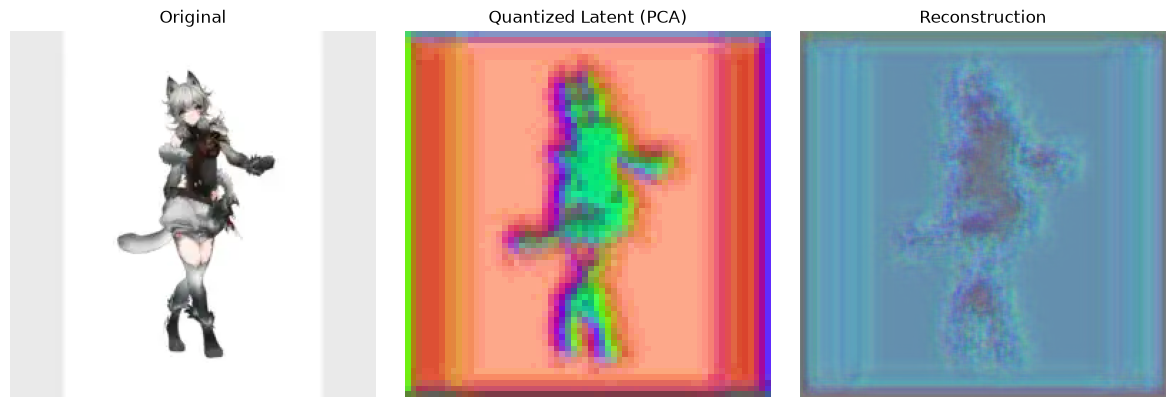

Epoch 1/20  Loss=0.50842:   0%|          | 1/6407 [00:01<2:27:32,  1.38s/it]

latent: μ=0.080  σ=0.494   unique tokens=2


Epoch 1/20  Loss=0.40317:   0%|          | 2/6407 [00:02<1:22:34,  1.29it/s]

time=2.627023220062256 loss=0.40317 latent μ=0.285 σ=1.155


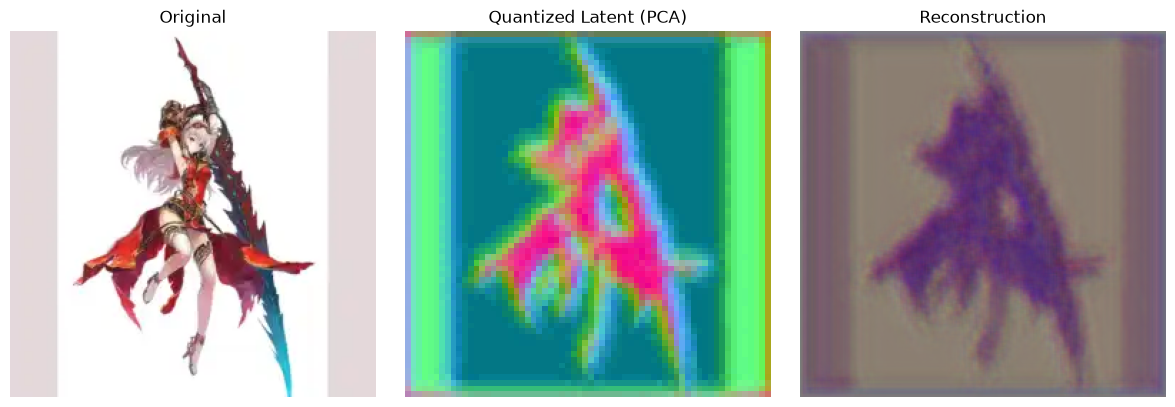

Epoch 1/20  Loss=0.40317:   0%|          | 3/6407 [00:03<1:47:40,  1.01s/it]

latent: μ=0.041  σ=0.498   unique tokens=2


Epoch 1/20  Loss=0.46387:   0%|          | 6/6407 [00:04<55:08,  1.93it/s]  

time=4.9489710330963135 loss=0.46387 latent μ=0.168 σ=1.278


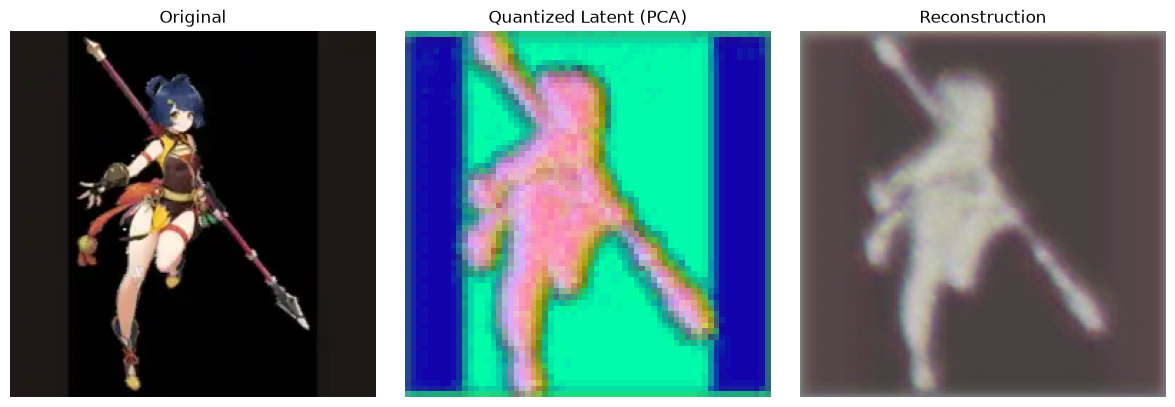

Epoch 1/20  Loss=0.46387:   0%|          | 7/6407 [00:05<1:13:04,  1.46it/s]

latent: μ=0.022  σ=0.499   unique tokens=2


Epoch 1/20  Loss=0.28110:   0%|          | 16/6407 [00:08<38:43,  2.75it/s] 

time=9.131182670593262 loss=0.28110 latent μ=0.251 σ=1.309


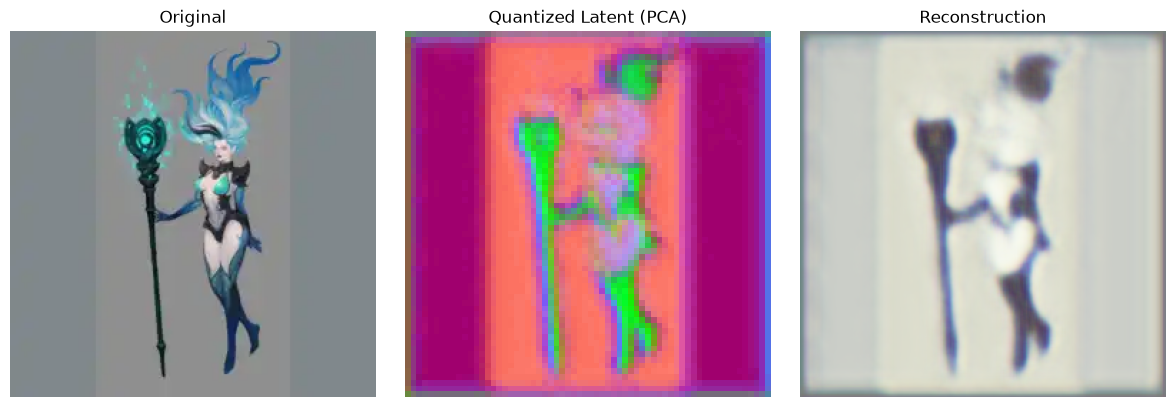

Epoch 1/20  Loss=0.28110:   0%|          | 17/6407 [00:08<47:40,  2.23it/s]

latent: μ=0.047  σ=0.498   unique tokens=2


Epoch 1/20  Loss=0.19957:   1%|          | 38/6407 [00:16<37:39,  2.82it/s]

time=17.189394235610962 loss=0.19957 latent μ=0.261 σ=1.553


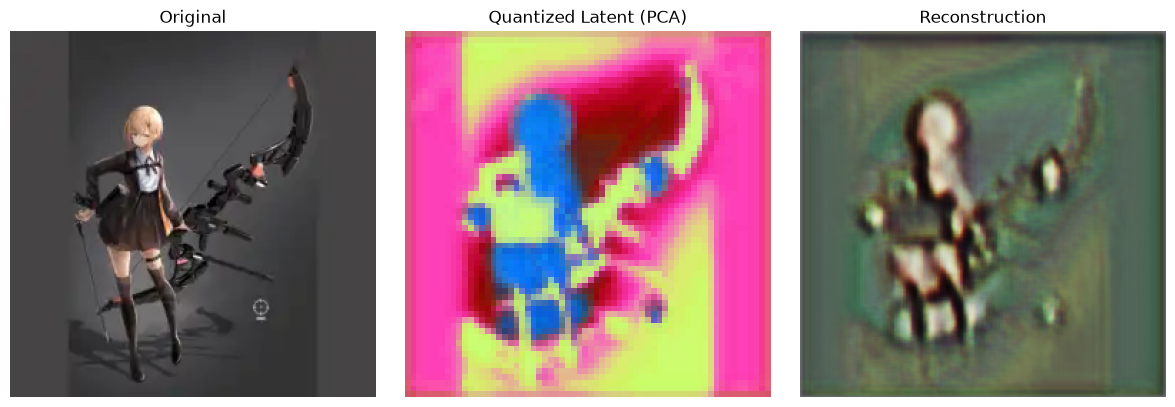

Epoch 1/20  Loss=0.19957:   1%|          | 39/6407 [00:16<46:53,  2.26it/s]

latent: μ=0.050  σ=0.498   unique tokens=2


Epoch 1/20  Loss=0.12902:   1%|▏         | 83/6407 [00:32<37:52,  2.78it/s]

time=33.52679228782654 loss=0.12902 latent μ=0.127 σ=1.517


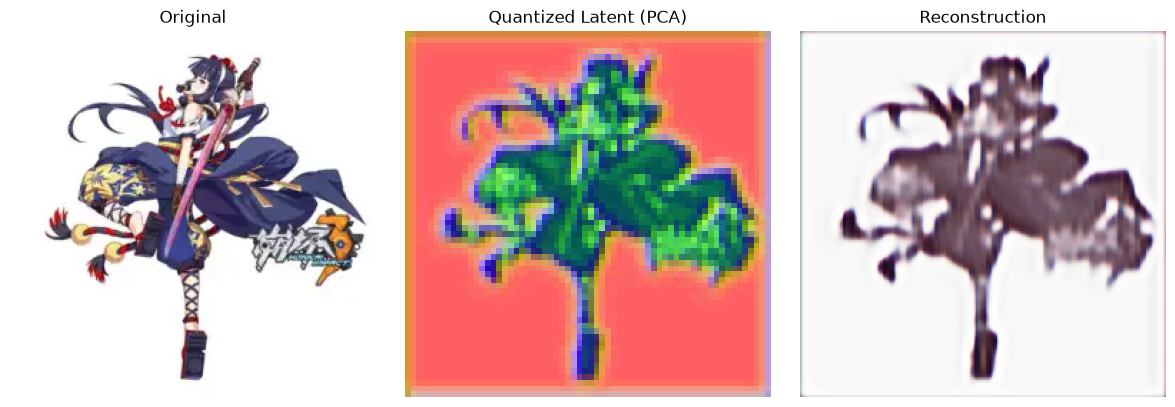

Epoch 1/20  Loss=0.12902:   1%|▏         | 84/6407 [00:33<46:32,  2.26it/s]

latent: μ=-0.015  σ=0.500   unique tokens=2


Epoch 1/20  Loss=0.14134:   3%|▎         | 172/6407 [01:05<36:55,  2.81it/s]

time=65.54520630836487 loss=0.14134 latent μ=0.121 σ=1.695


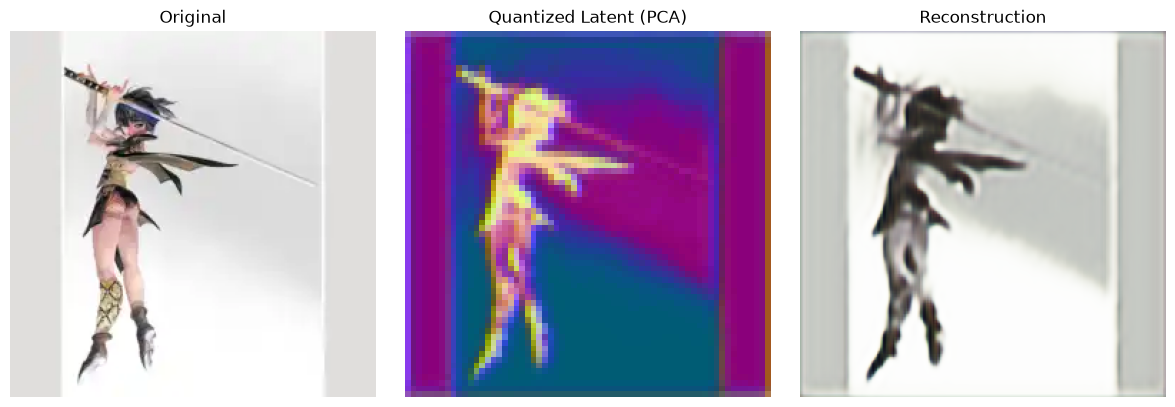

Epoch 1/20  Loss=0.14134:   3%|▎         | 173/6407 [01:05<46:35,  2.23it/s]

latent: μ=-0.030  σ=0.499   unique tokens=2


Epoch 1/20  Loss=0.06896:   5%|▌         | 351/6407 [02:09<36:14,  2.79it/s]

time=129.80218935012817 loss=0.06896 latent μ=0.064 σ=1.844


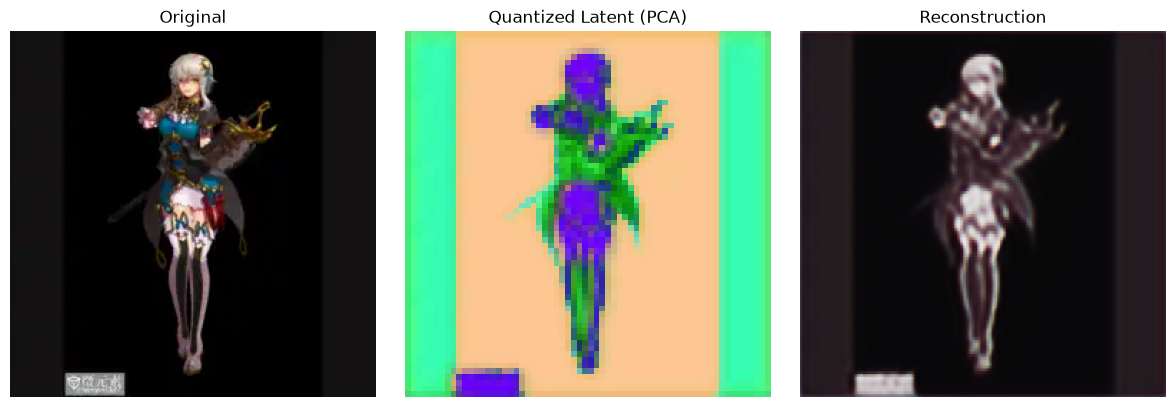

Epoch 1/20  Loss=0.06896:   5%|▌         | 352/6407 [02:09<44:29,  2.27it/s]

latent: μ=0.012  σ=0.500   unique tokens=2


Epoch 1/20  Loss=0.06704:  11%|█         | 710/6407 [04:17<33:21,  2.85it/s]

time=257.82794880867004 loss=0.06704 latent μ=0.020 σ=1.577


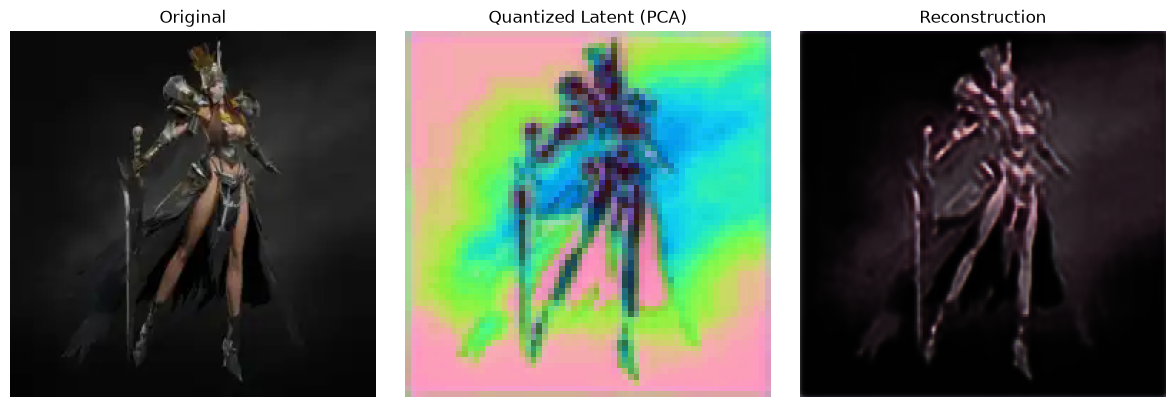

Epoch 1/20  Loss=0.06704:  11%|█         | 711/6407 [04:17<40:54,  2.32it/s]

latent: μ=-0.046  σ=0.498   unique tokens=2


Epoch 1/20  Loss=0.03713:  22%|██▏       | 1431/6407 [08:33<29:34,  2.80it/s]

time=514.1682605743408 loss=0.03713 latent μ=-0.061 σ=1.525


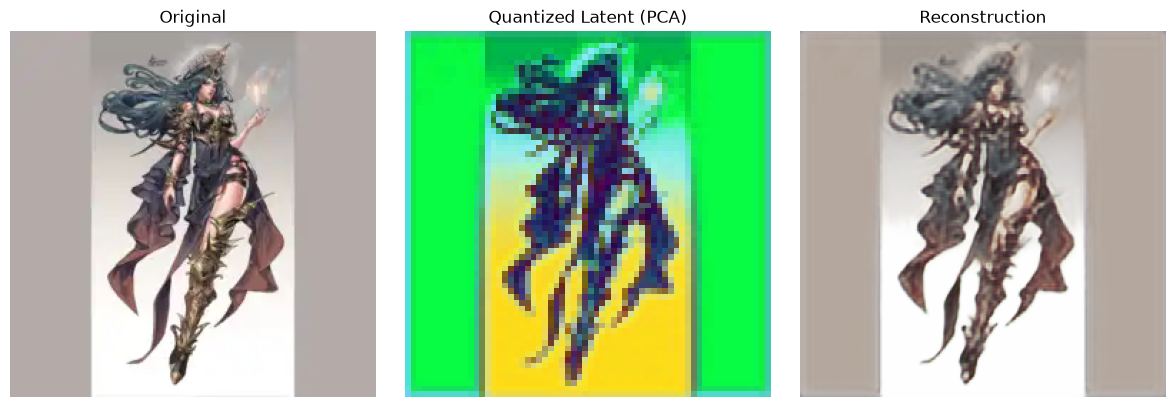

Epoch 1/20  Loss=0.03713:  22%|██▏       | 1432/6407 [08:33<36:37,  2.26it/s]

latent: μ=-0.143  σ=0.479   unique tokens=2


Epoch 1/20  Loss=0.04198:  45%|████▌     | 2900/6407 [17:05<19:56,  2.93it/s]

time=1026.3625333309174 loss=0.04198 latent μ=-0.154 σ=1.279


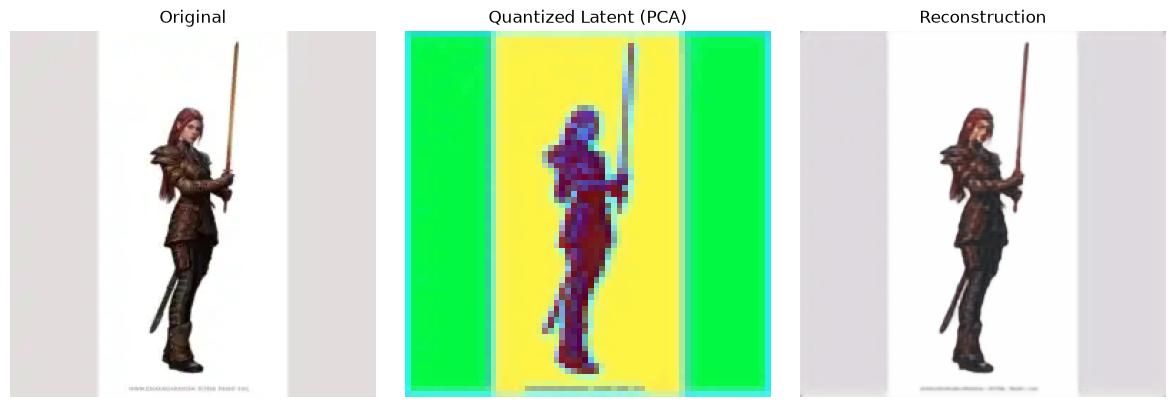

Epoch 1/20  Loss=0.04198:  45%|████▌     | 2901/6407 [17:06<24:58,  2.34it/s]

latent: μ=-0.120  σ=0.485   unique tokens=2


Epoch 1/20  Loss=0.03201:  89%|████████▉ | 5700/6407 [34:10<04:42,  2.50it/s]

time=2050.6409618854523 loss=0.03201 latent μ=-0.195 σ=1.295


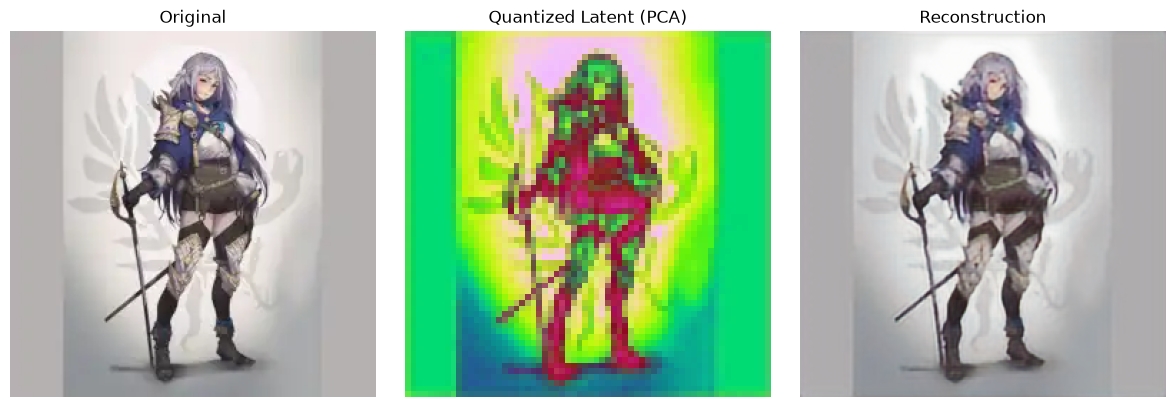

Epoch 1/20  Loss=0.03201:  89%|████████▉ | 5701/6407 [34:10<05:43,  2.06it/s]

latent: μ=-0.178  σ=0.467   unique tokens=2


Epoch  1: 0.049523


Epoch 2/20  Loss=0.01245:  69%|██████▊   | 4390/6407 [29:24<13:30,  2.49it/s]

time=4098.966094970703 loss=0.01245 latent μ=-0.217 σ=1.336


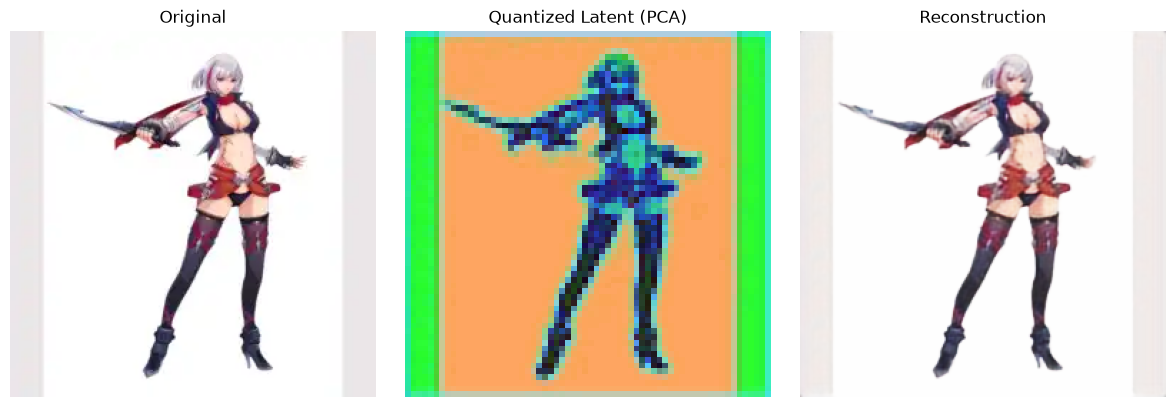

Epoch 2/20  Loss=0.01245:  69%|██████▊   | 4391/6407 [29:25<16:46,  2.00it/s]

latent: μ=-0.118  σ=0.486   unique tokens=2


Epoch  2: 0.024502


Epoch  3: 0.017621


Epoch 4/20  Loss=0.01556:  28%|██▊       | 1776/6407 [11:53<30:53,  2.50it/s]

time=8195.23386144638 loss=0.01556 latent μ=-0.242 σ=1.112


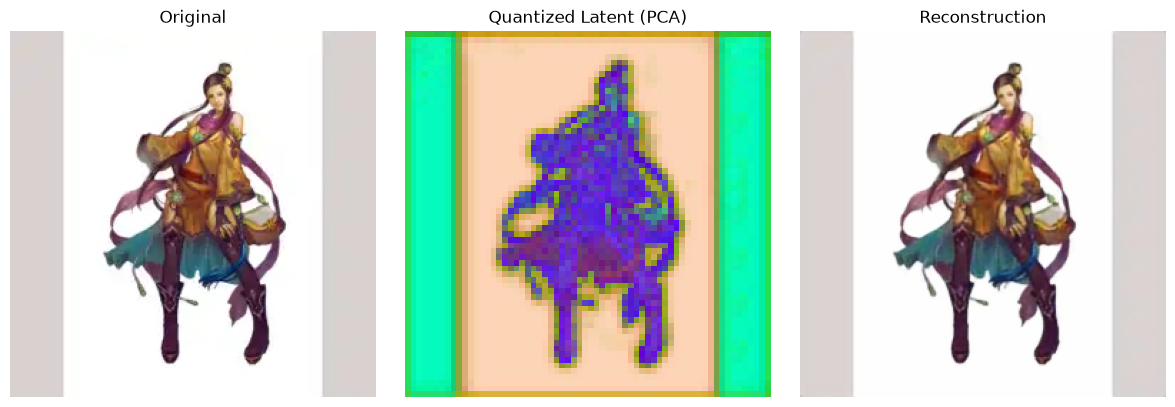

Epoch 4/20  Loss=0.01556:  28%|██▊       | 1777/6407 [11:53<37:03,  2.08it/s]

latent: μ=-0.148  σ=0.478   unique tokens=2


Epoch  4: 0.015159


Epoch  5: 0.013338


Epoch  6: 0.012196


Epoch 7/20  Loss=0.01473:  46%|████▌     | 2953/6407 [19:45<23:09,  2.49it/s]

time=16387.335678339005 loss=0.01473 latent μ=-0.258 σ=1.101


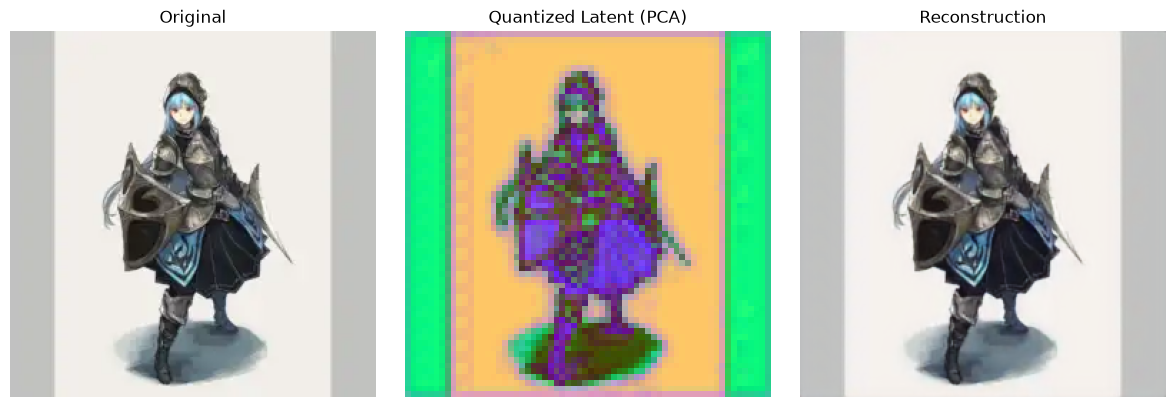

Epoch 7/20  Loss=0.01473:  46%|████▌     | 2954/6407 [19:46<27:54,  2.06it/s]

latent: μ=-0.192  σ=0.462   unique tokens=2


KeyboardInterrupt: 

In [9]:
epochs = 20
loss_history = []
import time
t0 = time.time()
display_interval = 1
next_display = t0 + display_interval
loss_fn = lpips.LPIPS(net='alex').to(device)
for epoch in range(epochs):
    autoencoder.train()
    running_loss = 0.0
    progress = tqdm(train_loader, leave=False)
    for imgs in progress:
        imgs = imgs.to(device)
        optimizer.zero_grad()
        reconstructions, latents, q_out, token_ids = autoencoder(imgs)
        #print(reconstructions.shape, latents.shape, q_out.shape, token_ids.shape)
        #loss = F.mse_loss(reconstructions, imgs)
        loss = (
            F.l1_loss(reconstructions, imgs)
            + 0.2 * loss_fn(reconstructions, imgs).mean()
        )
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        progress.set_description(
            f"Epoch {epoch+1}/{epochs}  Loss={loss.item():.5f}"
        )
        if time.time() > next_display:
            next_display = time.time() + display_interval
            display_interval *= 2
            print(
                f"time={time.time() - t0} "
                f"loss={loss.item():.5f} "
                f"latent μ={latents.mean():.3f} "
                f"σ={latents.std():.3f}"
            )
            show_reconstructions(autoencoder, imgs)

    epoch_loss = running_loss / len(train_loader)
    loss_history.append(epoch_loss)

    print(f"Epoch {epoch+1:2d}: {epoch_loss:.6f}")